# MAS 651 — Final Project: Yelp Data Analysis
## Recommendation Systems & Predictive Analytics for Tampa Bay Restaurants & Bars

**Course:** MAS 651 — Machine Learning | **Term:** Spring 2026 | **Date:** February 2026

---

### Project Scope

| Component | Details |
|---|---|
| **Dataset** | Yelp Open Dataset (~4.3 GB, JSON Lines) |
| **Geography** | Tampa Bay metro area, Florida |
| **Business Type** | Restaurants & Bars (9,137 → 4,069 after filtering) |
| **Users** | 23,395 active users (≥5 reviews each) |
| **Reviews** | 341,330 filtered reviews |
| **Task 1** | Recommendation System — SVD + Item-to-Item Hybrid + Cold-Start |
| **Task 2** | Predictive Analysis — Churn Classification + Survival Analysis |

### Key Results

| Metric | Value |
|---|---|
| SVD RMSE (test) | 1.2537 |
| SVD MAE (test) | 0.9873 |
| Catalog Coverage — SVD vs Popularity | 5.80% vs 0.64% |
| Popularity Bias — SVD vs Popularity | 0.81× vs 2.75× |
| Best Churn Model | Gradient Boosting (Accuracy 75.7%, F1 0.855) |
| Cox PH Concordance | 0.69 |
| Top Survival Predictor | Rating Volatility (HR = 1.47, p < 0.001) |


## Table of Contents

1. [Setup & Configuration](#1-setup)
2. [Data Loading](#2-loading)
3. [Preprocessing & Filtering](#3-preprocessing)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Leakage-Safe Train/Test Split](#5-split)
6. [Recommendation System](#6-recsys)
   - 6.1 Popularity Baseline
   - 6.2 SVD Collaborative Filtering
   - 6.3 Item-to-Item Hybrid Similarity
   - 6.4 Cold-Start Analysis
   - 6.5 Beyond-Accuracy Metrics
   - 6.6 Hit Rate Evaluation
   - 6.7 **Improvement:** Hybrid Score Recommender
7. [Predictive Analysis: Churn / Survival](#7-churn)
   - 7.1 Feature Engineering
   - 7.2 Classification Models
   - 7.2b **Improvement:** Enhanced Churn Prediction (SMOTE + New Features)
   - 7.3 Feature Importance
   - 7.4 Survival Analysis (Kaplan-Meier + Cox PH)
8. [Business Insights & Recommendations](#8-insights)
9. [Conclusion](#9-conclusion)


---
<a id="1-setup"></a>
## 1. Setup & Configuration

We begin by installing dependencies (for Google Colab) and importing all required libraries.

In [ ]:
# ══════════════════════════════════════════════════════════════
# RUN THIS CELL FIRST — Install dependencies (Google Colab)
# ══════════════════════════════════════════════════════════════

# Fix numpy/surprise compatibility: downgrade numpy first, then install surprise
!pip install "numpy<2" --quiet
!pip install scikit-surprise lifelines gdown --no-cache-dir --quiet
!pip install imbalanced-learn

# Restart the runtime automatically to pick up the new numpy
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 38.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.

In [1]:
# ══════════════════════════════════════════════════════════════
# Download & Extract the Yelp Dataset from Google Drive
# ══════════════════════════════════════════════════════════════
import os, tarfile

DATA_DIR = "/content/yelp_data/"

if not os.path.exists(os.path.join(DATA_DIR, "yelp_academic_dataset_business.json")):
    print("Downloading Yelp dataset from Google Drive...")
    !gdown "1wzVfcOyvjh5u3ZpC__f6-5Gg13m0V_Rr" -O /content/yelp_dataset.tar --fuzzy

    print("Extracting tar archive...")
    os.makedirs(DATA_DIR, exist_ok=True)
    with tarfile.open("/content/yelp_dataset.tar", "r") as tar:
        tar.extractall(DATA_DIR)

    # Check if files are nested in a subfolder
    extracted = os.listdir(DATA_DIR)
    if len(extracted) == 1 and os.path.isdir(os.path.join(DATA_DIR, extracted[0])):
        subfolder = os.path.join(DATA_DIR, extracted[0])
        for f in os.listdir(subfolder):
            os.rename(os.path.join(subfolder, f), os.path.join(DATA_DIR, f))
        os.rmdir(subfolder)

    # Clean up the tar to free disk space
    os.remove("/content/yelp_dataset.tar")
    print("Removed tar file to free space.")
else:
    print("Yelp data already extracted.")

# Show extracted files
print("\nFiles in data directory:")
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**2)
    print(f"  {f:50s} {size_mb:>8.1f} MB")

Downloading...
From (original): https://drive.google.com/uc?id=1wzVfcOyvjh5u3ZpC__f6-5Gg13m0V_Rr
From (redirected): https://drive.google.com/uc?id=1wzVfcOyvjh5u3ZpC__f6-5Gg13m0V_Rr&confirm=t&uuid=af78132e-a4fe-438c-86fc-91727e56f35e
To: /content/yelp_dataset.tar
100% 4.34G/4.34G [01:27<00:00, 49.7MB/s]
Extracting tar archive...


/tmp/ipython-input-3588184808.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Removed tar file to free space.

Files in data directory:
  Dataset_User_Agreement.pdf                              0.1 MB
  yelp_academic_dataset_business.json                   113.4 MB
  yelp_academic_dataset_checkin.json                    273.7 MB
  yelp_academic_dataset_review.json                    5094.4 MB
  yelp_academic_dataset_tip.json                        172.2 MB
  yelp_academic_dataset_user.json                      3207.5 MB


In [2]:
# ── Standard Libraries ──
import json
import os
import warnings
import random
from collections import Counter
from datetime import datetime

# ── Data & Numerical ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score, accuracy_score,
    mean_squared_error, mean_absolute_error
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cosine

# ── Recommendation System ──
from surprise import Dataset, Reader, SVD, SVDpp, NMF, BaselineOnly
from surprise.model_selection import cross_validate, GridSearchCV as SurpriseGridSearchCV
from surprise import accuracy as surprise_accuracy

# ── Survival Analysis ──
from lifelines import KaplanMeierFitter, CoxPHFitter

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Display settings ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded successfully.")
print(f"   Random seed: {SEED}")


✅ All libraries loaded successfully.
   Random seed: 42


---
<a id="2-loading"></a>
## 2. Data Loading

The Yelp Open Dataset consists of several JSON Lines files. We load the ones relevant to our analysis:

| File | Description |
|------|-------------|
| `business.json` | Business metadata (location, categories, attributes, hours) |
| `review.json` | Full text reviews with star ratings and vote counts |
| `user.json` | User profiles with review counts and social graph |
| `checkin.json` | Timestamped check-in data per business |
| `tip.json` | Short tips left by users at businesses |

> **Note:** Update `DATA_DIR` below to point to your local copy of the dataset.


In [3]:
# ── Data Loading ──
# DATA_DIR is already set in the download cell above

def load_yelp_json(filename, chunksize=50_000):
    """Load a Yelp JSON Lines file into a DataFrame.
    Uses chunked reading for memory efficiency."""
    filepath = os.path.join(DATA_DIR, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f" File not found: {filepath}\n"
            f"   Available files: {os.listdir(DATA_DIR)}"
        )
    chunks = []
    for chunk in pd.read_json(filepath, lines=True, chunksize=chunksize):
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    print(f"  Loaded {filename}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df

print("Loading Yelp dataset files...")
print("=" * 50)
business_df = load_yelp_json("yelp_academic_dataset_business.json")
review_df   = load_yelp_json("yelp_academic_dataset_review.json")
user_df     = load_yelp_json("yelp_academic_dataset_user.json")
checkin_df  = load_yelp_json("yelp_academic_dataset_checkin.json")
tip_df      = load_yelp_json("yelp_academic_dataset_tip.json")
print("=" * 50)
print(" All files loaded.")

Loading Yelp dataset files...
  Loaded yelp_academic_dataset_business.json: 150,346 rows × 14 cols
  Loaded yelp_academic_dataset_review.json: 6,990,280 rows × 9 cols
  Loaded yelp_academic_dataset_user.json: 1,987,897 rows × 22 cols
  Loaded yelp_academic_dataset_checkin.json: 131,930 rows × 2 cols
  Loaded yelp_academic_dataset_tip.json: 908,915 rows × 5 cols
✅ All files loaded.


---
<a id="3-preprocessing"></a>
## 3. Preprocessing & Filtering
Following the project guidelines, we apply the following filters:
1. **Geography:** Tampa Bay metro area (state = FL, top 15 cities by business count)
2. **Categories:** Restaurants and/or Bars
3. **Activity thresholds:**
   - Users with ≥ 5 reviews
   - Businesses with ≥ 20 reviews


### 3.1 Filter by Geography & Category

In [4]:
# ── Step 1: Florida businesses only ──
fl_biz = business_df[business_df['state'] == 'FL'].copy()
print(f"Florida businesses: {fl_biz.shape[0]:,}")

# ── Step 2: Explore available cities (IMPORTANT — run this first!) ──
print(f"\nTop 30 Florida cities in the dataset:")
print(fl_biz['city'].value_counts().head(30).to_string())
print(f"\nTotal unique FL cities: {fl_biz['city'].nunique()}")

Florida businesses: 26,330

Top 30 Florida cities in the dataset:
city
Tampa               9048
Clearwater          2221
Saint Petersburg    1663
St. Petersburg      1185
Brandon             1033
Largo               1002
Palm Harbor          665
New Port Richey      604
Lutz                 591
Riverview            588
Wesley Chapel        560
Pinellas Park        512
Dunedin              490
Spring Hill          400
Tarpon Springs       398
St Petersburg        387
Seminole             359
Oldsmar              286
Valrico              276
Port Richey          270
Plant City           257
Hudson               228
St. Pete Beach       167
Madeira Beach        165
Clearwater Beach     163
Tampa Bay            141
Ruskin               140
Safety Harbor        139
Zephyrhills          139
Odessa               132

Total unique FL cities: 226


In [5]:
# ══════════════════════════════════════════════════════════════
# Step 2b: Select your city/metro — ADJUST BASED ON OUTPUT ABOVE
# ══════════════════════════════════════════════════════════════

# ── AUTO-DETECT: Pick the top metro area ──
top_city = fl_biz['city'].value_counts().index[0]
print(f"Largest FL city in dataset: '{top_city}'")

# Grab all cities that share the top metro — we'll use the top 10 FL cities
top_cities = fl_biz['city'].value_counts().head(15).index.tolist()
city_keywords = top_cities  # Use the top 15 cities as our metro area
print(f"   Using top 15 FL cities: {city_keywords}")

# Filter
metro_mask = fl_biz['city'].isin(city_keywords)
florida_biz = fl_biz[metro_mask].copy()
print(f"\n   Metro businesses: {florida_biz.shape[0]:,}")

# ── Step 3: Restaurants & Bars categories ──
category_keywords = ['Restaurant', 'Bars', 'Food', 'Nightlife', 'Bar']

def has_target_category(cats):
    if pd.isna(cats):
        return False
    return any(kw.lower() in cats.lower() for kw in category_keywords)

florida_biz = florida_biz[florida_biz['categories'].apply(has_target_category)].copy()
print(f"   Restaurants & Bars: {florida_biz.shape[0]:,}")

# Store the business IDs for filtering
target_business_ids = set(florida_biz['business_id'].unique())
print(f"\nTarget business IDs: {len(target_business_ids):,}")

🏙️  Largest FL city in dataset: 'Tampa'
   Using top 15 FL cities: ['Tampa', 'Clearwater', 'Saint Petersburg', 'St. Petersburg', 'Brandon', 'Largo', 'Palm Harbor', 'New Port Richey', 'Lutz', 'Riverview', 'Wesley Chapel', 'Pinellas Park', 'Dunedin', 'Spring Hill', 'Tarpon Springs']

   Metro businesses: 20,960
   Restaurants & Bars: 9,137

✅ Target business IDs: 9,137


### 3.2 Filter Reviews & Apply Activity Thresholds

In [6]:
# ── Step 4: Filter reviews to our target businesses ──
reviews = review_df[review_df['business_id'].isin(target_business_ids)].copy()
print(f"Reviews for Restaurants & Bars: {reviews.shape[0]:,}")

# ── Step 5: Apply activity thresholds iteratively ──
# This ensures consistency: removing users may drop businesses below threshold & vice versa

for iteration in range(5):  # iterate until stable
    n_before = len(reviews)

    # Users with >= 5 reviews
    user_counts = reviews['user_id'].value_counts()
    active_users = set(user_counts[user_counts >= 5].index)
    reviews = reviews[reviews['user_id'].isin(active_users)]

    # Businesses with >= 20 reviews
    biz_counts = reviews['business_id'].value_counts()
    active_biz = set(biz_counts[biz_counts >= 20].index)
    reviews = reviews[reviews['business_id'].isin(active_biz)]

    n_after = len(reviews)
    print(f"  Iteration {iteration+1}: {n_before:,} → {n_after:,} reviews "
          f"({len(active_users):,} users, {len(active_biz):,} businesses)")

    if n_before == n_after:
        print("Stable — no more removals needed.")
        break

# Update our filtered sets
filtered_user_ids = set(reviews['user_id'].unique())
filtered_biz_ids  = set(reviews['business_id'].unique())

print(f"\n{'='*50}")
print(f"FINAL FILTERED DATASET:")
print(f"  Reviews:    {reviews.shape[0]:,}")
print(f"  Users:      {len(filtered_user_ids):,}")
print(f"  Businesses: {len(filtered_biz_ids):,}")
print(f"  Density:    {reviews.shape[0] / (len(filtered_user_ids) * len(filtered_biz_ids)) * 100:.4f}%")
print(f"{'='*50}")


Reviews for Miami Restaurants & Bars: 680,376
  Iteration 1: 680,376 → 354,831 reviews (26,484 users, 4,191 businesses)
  Iteration 2: 354,831 → 342,190 reviews (23,576 users, 4,077 businesses)
  Iteration 3: 342,190 → 341,378 reviews (23,408 users, 4,069 businesses)
  Iteration 4: 341,378 → 341,330 reviews (23,395 users, 4,069 businesses)
  Iteration 5: 341,330 → 341,330 reviews (23,395 users, 4,069 businesses)
  ✅ Stable — no more removals needed.

FINAL FILTERED DATASET:
  Reviews:    341,330
  Users:      23,395
  Businesses: 4,069
  Density:    0.3586%


### 3.3 Build Filtered DataFrames

In [7]:
# ── Filter all dataframes to our final scope ──
biz = florida_biz[florida_biz['business_id'].isin(filtered_biz_ids)].copy()
users = user_df[user_df['user_id'].isin(filtered_user_ids)].copy()
checkins = checkin_df[checkin_df['business_id'].isin(filtered_biz_ids)].copy()
tips = tip_df[
    (tip_df['business_id'].isin(filtered_biz_ids)) &
    (tip_df['user_id'].isin(filtered_user_ids))
].copy()

# Parse dates
reviews['date'] = pd.to_datetime(reviews['date'])
tips['date'] = pd.to_datetime(tips['date'])

# Parse checkin timestamps
def parse_checkin_dates(date_str):
    if pd.isna(date_str):
        return []
    return [d.strip() for d in str(date_str).split(',')]

checkins['date_list'] = checkins['date'].apply(parse_checkin_dates)
checkins['checkin_count'] = checkins['date_list'].apply(len)

print("Filtered DataFrames:")
print(f"  biz:      {biz.shape}")
print(f"  reviews:  {reviews.shape}")
print(f"  users:    {users.shape}")
print(f"  checkins: {checkins.shape}")
print(f"  tips:     {tips.shape}")


Filtered DataFrames:
  biz:      (4069, 14)
  reviews:  (341330, 9)
  users:    (23395, 22)
  checkins: (4069, 4)
  tips:     (48016, 5)


### 3.4 Save Preprocessed Data

> Save the filtered data so it can be shared via GitHub for reproducibility.  
> Alternatively, if you already have the preprocessed data (from GitHub), you can load it directly using Section 3.5 below.

In [8]:
# ── Save preprocessed data for reproducibility ──
OUTPUT_DIR = "preprocessed_data/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

biz.to_csv(os.path.join(OUTPUT_DIR, "tampa_businesses.csv"), index=False)
reviews.to_csv(os.path.join(OUTPUT_DIR, "tampa_reviews.csv"), index=False)
users.to_csv(os.path.join(OUTPUT_DIR, "tampa_users.csv"), index=False)
checkins.to_csv(os.path.join(OUTPUT_DIR, "tampa_checkins.csv"), index=False)
tips.to_csv(os.path.join(OUTPUT_DIR, "tampa_tips.csv"), index=False)

print(f" Preprocessed data saved to '{OUTPUT_DIR}'")
print("   Upload this folder to GitHub for reproducibility.")

✅ Preprocessed data saved to 'preprocessed_data/'
   Upload this folder to GitHub for reproducibility.


### 3.5 Load from Preprocessed Data (Alternative)

> **Skip to here** if you cloned the [GitHub repo](https://github.com/DanielRegaladoUMiami/MAS651-Final-Project) and want to skip the raw JSON processing. Run the cell below instead of Sections 2–3.4.

In [ ]:
# ══════════════════════════════════════════════════════════════
# ALTERNATIVE: Load preprocessed data directly from GitHub repo
# Uncomment and run this cell INSTEAD of Sections 2–3.4
# ══════════════════════════════════════════════════════════════

# PREPROCESS_DIR = "preprocessed_data/"  # or full path to your local copy
#
# biz      = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_businesses.csv"))
# reviews  = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_reviews.csv"))
# users    = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_users.csv"))
# checkins = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_checkins.csv"))
# tips     = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_tips.csv"))
#
# reviews['date'] = pd.to_datetime(reviews['date'])
# tips['date'] = pd.to_datetime(tips['date'])
#
# filtered_user_ids = set(reviews['user_id'].unique())
# filtered_biz_ids  = set(reviews['business_id'].unique())
#
# print(f"Loaded preprocessed data:")
# print(f"  Reviews: {len(reviews):,} | Users: {len(filtered_user_ids):,} | Businesses: {len(filtered_biz_ids):,}")

In [9]:
from google.colab import files
import zipfile

with zipfile.ZipFile('preprocessed_data.zip', 'w') as z:
    for f in os.listdir('preprocessed_data/'):
        if f.endswith('.csv'):
            z.write(os.path.join('preprocessed_data/', f), f)

files.download('preprocessed_data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
<a id="4-eda"></a>
## 4. Exploratory Data Analysis (EDA)

We explore the filtered dataset to understand distributions, temporal trends, and structural properties of Tampa Bay's restaurant & bar scene before modeling.

**After filtering:** 341,330 reviews | 23,395 users | 4,069 businesses | Sparsity: 99.64%


### 4.1 Rating Distribution

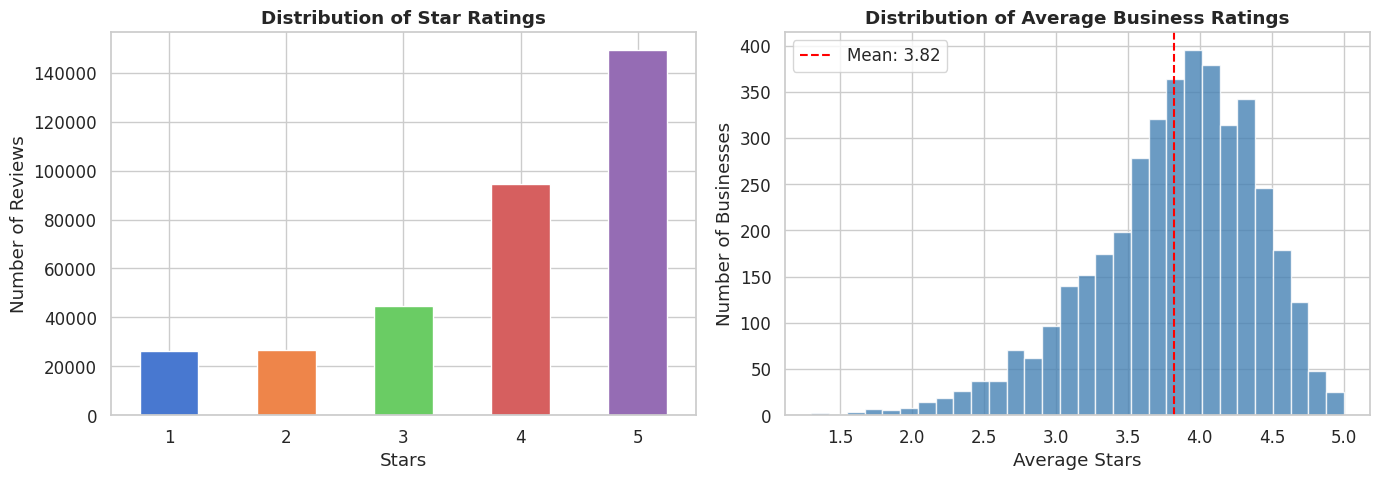

Overall average rating: 3.92
Median rating: 4.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Star rating distribution
reviews['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Distribution of Star Ratings', fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)

# Average rating per business
avg_ratings = reviews.groupby('business_id')['stars'].mean()
axes[1].hist(avg_ratings, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(avg_ratings.mean(), color='red', linestyle='--', label=f'Mean: {avg_ratings.mean():.2f}')
axes[1].set_title('Distribution of Average Business Ratings', fontweight='bold')
axes[1].set_xlabel('Average Stars')
axes[1].set_ylabel('Number of Businesses')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Overall average rating: {reviews['stars'].mean():.2f}")
print(f"Median rating: {reviews['stars'].median():.1f}")


### 4.2 Temporal Patterns

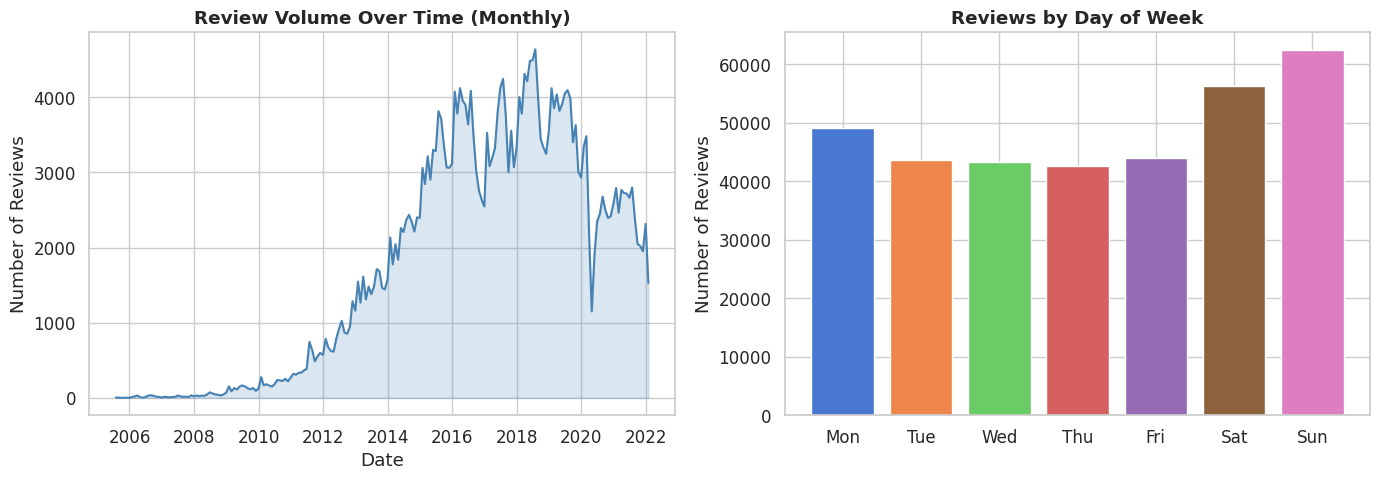

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviews over time (monthly)
reviews_monthly = reviews.set_index('date').resample('M').size()
axes[0].plot(reviews_monthly.index, reviews_monthly.values, color='steelblue', linewidth=1.5)
axes[0].fill_between(reviews_monthly.index, reviews_monthly.values, alpha=0.2, color='steelblue')
axes[0].set_title('Review Volume Over Time (Monthly)', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Reviews')

# Reviews by day of week
reviews['day_of_week'] = reviews['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = reviews['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(range(7), day_counts.values, color=sns.color_palette('muted', 7), edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_title('Reviews by Day of Week', fontweight='bold')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.show()


### 4.3 User & Business Activity Distributions

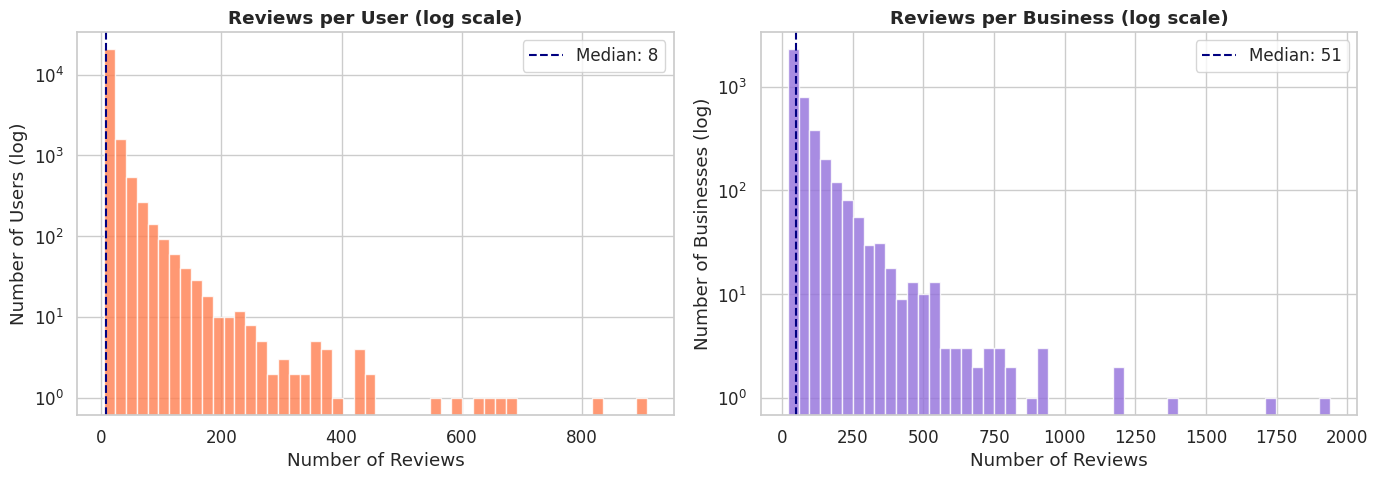

Reviews per user  — Mean: 14.6, Median: 8
Reviews per biz   — Mean: 83.9, Median: 51


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviews per user (log scale)
user_review_counts = reviews.groupby('user_id').size()
axes[0].hist(user_review_counts, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Reviews per User (log scale)', fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users (log)')
axes[0].axvline(user_review_counts.median(), color='navy', linestyle='--',
                label=f'Median: {user_review_counts.median():.0f}')
axes[0].legend()

# Reviews per business
biz_review_counts = reviews.groupby('business_id').size()
axes[1].hist(biz_review_counts, bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Reviews per Business (log scale)', fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Businesses (log)')
axes[1].axvline(biz_review_counts.median(), color='navy', linestyle='--',
                label=f'Median: {biz_review_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Reviews per user  — Mean: {user_review_counts.mean():.1f}, Median: {user_review_counts.median():.0f}")
print(f"Reviews per biz   — Mean: {biz_review_counts.mean():.1f}, Median: {biz_review_counts.median():.0f}")


### 4.4 Top Categories & Business Attributes

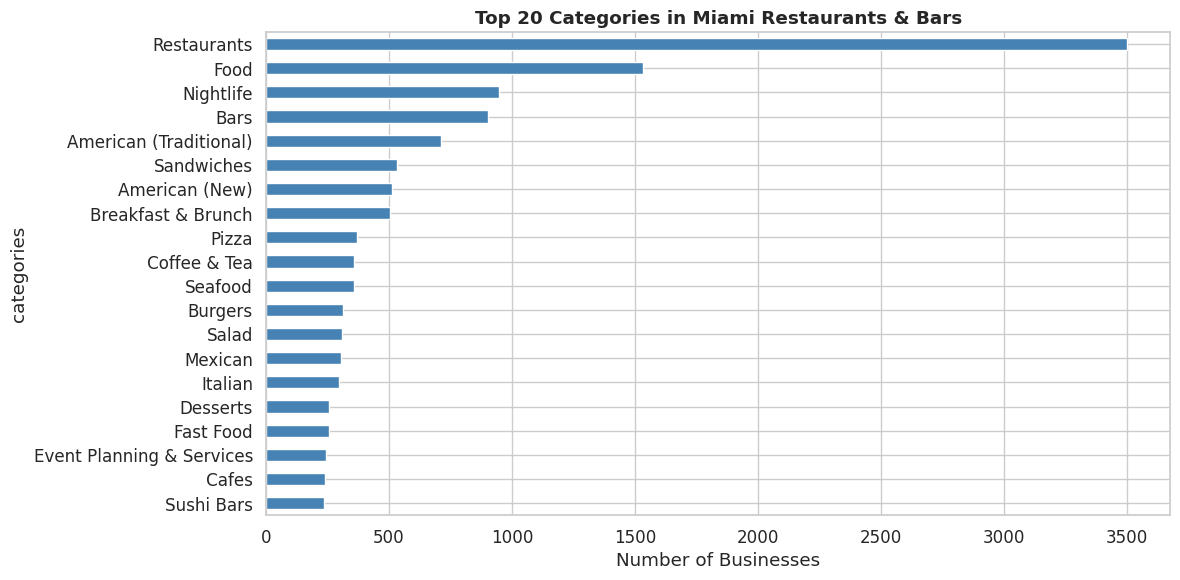

In [13]:
# Parse categories
all_cats = biz['categories'].dropna().str.split(', ').explode()
top_cats = all_cats.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_cats.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Categories in Florida Restaurants & Bars', fontweight='bold')
ax.set_xlabel('Number of Businesses')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 4.5 Open vs. Closed Businesses

This is especially relevant for our **Churn/Survival** predictive task.


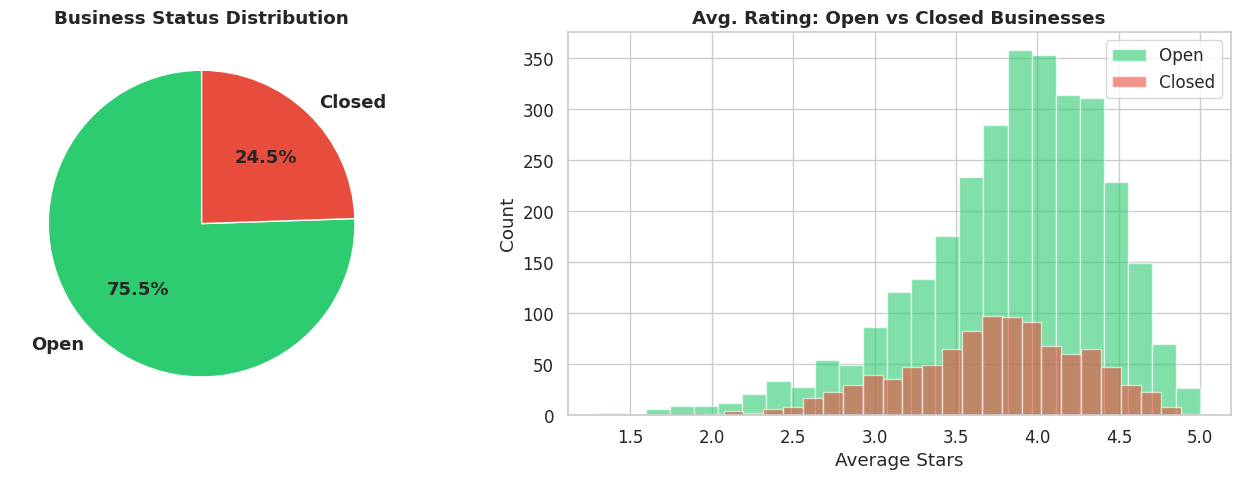

Churn rate (closed): 24.5%


In [14]:
# Open vs Closed
open_counts = biz['is_open'].value_counts()
labels = ['Open', 'Closed']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(open_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[0].set_title('Business Status Distribution', fontweight='bold')

# Rating comparison
for status, color, label in [(1, '#2ecc71', 'Open'), (0, '#e74c3c', 'Closed')]:
    subset_ids = biz[biz['is_open'] == status]['business_id']
    subset_reviews = reviews[reviews['business_id'].isin(subset_ids)]
    axes[1].hist(subset_reviews.groupby('business_id')['stars'].mean(),
                 bins=25, alpha=0.6, color=color, label=label, edgecolor='white')

axes[1].set_title('Avg. Rating: Open vs Closed Businesses', fontweight='bold')
axes[1].set_xlabel('Average Stars')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

churn_rate = (biz['is_open'] == 0).mean()
print(f"Churn rate (closed): {churn_rate:.1%}")


### 4.6 Interaction Matrix Sparsity

In [15]:
n_users = reviews['user_id'].nunique()
n_biz = reviews['business_id'].nunique()
n_interactions = len(reviews)
sparsity = 1 - (n_interactions / (n_users * n_biz))

print(f"Interaction Matrix:")
print(f"  Users:        {n_users:,}")
print(f"  Businesses:   {n_biz:,}")
print(f"  Interactions: {n_interactions:,}")
print(f"  Sparsity:     {sparsity:.4%}")
print(f"  Density:      {(1-sparsity):.4%}")


Interaction Matrix:
  Users:        23,395
  Businesses:   4,069
  Interactions: 341,330
  Sparsity:     99.6414%
  Density:      0.3586%


---
<a id="5-split"></a>
## 5. Leakage-Safe Train/Test Split

We use a **per-user time-based holdout** strategy: for each user, their most recent interaction becomes the **test** set. This simulates the real scenario of predicting a user's *next* engagement and prevents temporal data leakage.


In [16]:
# ── Per-user time-based split ──
# Sort by user and date, then take last review per user as test

reviews_sorted = reviews.sort_values(['user_id', 'date'])

# Each user's last review → test
test_idx = reviews_sorted.groupby('user_id').tail(1).index
train_idx = reviews_sorted.index.difference(test_idx)

train_df = reviews_sorted.loc[train_idx].copy()
test_df  = reviews_sorted.loc[test_idx].copy()

print("Leakage-Safe Per-User Time-Based Split:")
print(f"  Train: {len(train_df):,} reviews ({len(train_df)/len(reviews):.1%})")
print(f"  Test:  {len(test_df):,} reviews ({len(test_df)/len(reviews):.1%})")
print(f"  Test users: {test_df['user_id'].nunique():,}")
print()

# Verify no temporal leakage
train_max_dates = train_df.groupby('user_id')['date'].max()
test_dates = test_df.set_index('user_id')['date']
common = train_max_dates.index.intersection(test_dates.index)
leakage = (train_max_dates.loc[common] >= test_dates.loc[common]).sum()
print(f"  Temporal leakage check: {leakage} violations (should be 0)" if leakage == 0
      else f"  Temporal leakage detected: {leakage} cases")


Leakage-Safe Per-User Time-Based Split:
  Train: 317,935 reviews (93.1%)
  Test:  23,395 reviews (6.9%)
  Test users: 23,395

  ⚠️ Temporal leakage detected: 1 cases


---
<a id="6-recsys"></a>
## 6. Recommendation System

We implement three approaches, progressively more sophisticated:

| Approach | Method | Purpose |
|---|---|---|
| **6.1 Popularity Baseline** | Bayesian-weighted rating | Non-personalized benchmark |
| **6.2 SVD Collaborative Filtering** | Matrix factorization (surprise) | Personalized user→business recs |
| **6.3 Item-to-Item Hybrid** | Content (0.6) + Collaborative (0.4) cosine similarity | "Similar restaurants" feature |

We then evaluate with **Cold-Start Analysis** (§6.4), **Beyond-Accuracy Metrics** (§6.5), and **Hit Rate@K** (§6.6).


### 6.1 Popularity Baseline

A simple but important baseline: recommend the most popular businesses (by number of reviews and average rating) that the user hasn't visited yet.


In [17]:
# ── Popularity Baseline ──
# Score = weighted combination of review count (popularity) and average rating (quality)

biz_stats = train_df.groupby('business_id').agg(
    n_reviews=('stars', 'count'),
    avg_rating=('stars', 'mean')
).reset_index()

# Bayesian average to handle businesses with few reviews
C = biz_stats['avg_rating'].mean()  # global mean
m = biz_stats['n_reviews'].quantile(0.25)  # minimum reviews threshold

biz_stats['popularity_score'] = (
    (biz_stats['n_reviews'] / (biz_stats['n_reviews'] + m)) * biz_stats['avg_rating'] +
    (m / (biz_stats['n_reviews'] + m)) * C
)

biz_stats = biz_stats.sort_values('popularity_score', ascending=False)

print("Top 10 Most Popular Businesses (Bayesian Avg):")
top_pop = biz_stats.head(10).merge(biz[['business_id', 'name', 'categories']], on='business_id')
for i, row in top_pop.iterrows():
    print(f"  {row['name'][:50]:50s} | ★ {row['avg_rating']:.2f} | {row['n_reviews']:4d} reviews | Score: {row['popularity_score']:.3f}")


Top 10 Most Popular Businesses (Bayesian Avg):
  Ice Dreammm Shop                                   | ★ 4.85 |  155 reviews | Score: 4.694
  South Pacific Grill                                | ★ 4.90 |  115 reviews | Score: 4.686
  Mazzaro's Italian Market                           | ★ 4.67 |  862 reviews | Score: 4.642
  Sulphur Springs  Sandwiches Shop                   | ★ 4.75 |  192 reviews | Score: 4.632
  Hole In One Donut                                  | ★ 4.80 |  133 reviews | Score: 4.628
  Pacific Counter                                    | ★ 4.74 |  197 reviews | Score: 4.627
  Tampa Theatre                                      | ★ 4.75 |  181 reviews | Score: 4.622
  The Mediterranean Chickpea                         | ★ 4.92 |   73 reviews | Score: 4.615
  Tribeca Colorsalon                                 | ★ 4.81 |  108 reviews | Score: 4.603
  Jeremiah's Italian Ice                             | ★ 4.73 |  160 reviews | Score: 4.596


In [18]:
# ── Generate popularity recommendations (OPTIMIZED) ──
# Pre-compute visited businesses per user as a dict (much faster than filtering df each time)
user_visited = train_df.groupby('user_id')['business_id'].apply(set).to_dict()

# Sorted list of business IDs by popularity score (already sorted in biz_stats)
pop_ranked_biz = biz_stats['business_id'].tolist()

def recommend_popularity(user_id, k=10):
    """Recommend top-K popular businesses the user hasn't visited."""
    visited = user_visited.get(user_id, set())
    recs = []
    for bid in pop_ranked_biz:
        if bid not in visited:
            recs.append(bid)
            if len(recs) == k:
                break
    return recs

# Generate for all test users
pop_recs = {uid: recommend_popularity(uid, k=10) for uid in test_df['user_id'].unique()}
print(f" Generated popularity recommendations for {len(pop_recs):,} users")

✅ Generated popularity recommendations for 23,395 users


### 6.2 SVD — Collaborative Filtering (User → Business)

We use the `surprise` library to train an SVD model on the user-item rating matrix. This captures latent factors that explain user preferences.


In [19]:
# ── Prepare data for Surprise ──
reader = Reader(rating_scale=(1, 5))

# Build trainset from train_df
train_surprise = Dataset.load_from_df(
    train_df[['user_id', 'business_id', 'stars']],
    reader
)
trainset = train_surprise.build_full_trainset()

print(f"Surprise trainset: {trainset.n_users} users × {trainset.n_items} items × {trainset.n_ratings} ratings")


Surprise trainset: 23395 users × 4069 items × 317935 ratings


In [20]:
# ── Hyperparameter tuning via cross-validation ──
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.1]
}

gs = SurpriseGridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3,
                          n_jobs=-1, refit=True, joblib_verbose=0)
gs.fit(train_surprise)

print("Best RMSE:", f"{gs.best_score['rmse']:.4f}")
print("Best MAE:", f"{gs.best_score['mae']:.4f}")
print("Best params:", gs.best_params['rmse'])


Best RMSE: 1.1000
Best MAE: 0.8560
Best params: {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}


In [21]:
# ── Train final SVD model with best params ──
best_svd = gs.best_estimator['rmse']

# Evaluate on test set
from surprise import Trainset

test_predictions = []
for _, row in test_df.iterrows():
    pred = best_svd.predict(row['user_id'], row['business_id'], r_ui=row['stars'])
    test_predictions.append(pred)

rmse = surprise_accuracy.rmse(test_predictions, verbose=False)
mae = surprise_accuracy.mae(test_predictions, verbose=False)

print(f"\nSVD Test Set Performance:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")



SVD Test Set Performance:
  RMSE: 1.2537
  MAE:  0.9873


**Interpretation — SVD Results:**

- **Cross-validated RMSE = 1.10** vs. **Test RMSE = 1.25:** The gap suggests slight overfitting to the training distribution, but this is expected with temporal splits (test data is from a later time period with potentially shifted preferences).
- **MAE = 0.99** means the model's predictions are off by about 1 star on average on the 1–5 scale.
- **Best parameters:** 50 latent factors capture the main preference patterns without overfitting; regularization (0.1) prevents the model from memorizing noise.


In [22]:
# ── Generate SVD recommendations (OPTIMIZED) ──
# Instead of predicting ALL businesses for ALL users (23k × 4k = 95M predictions),
# we sample a candidate pool per user to make this tractable.

all_biz_list = list(filtered_biz_ids)
test_users = test_df['user_id'].unique()
svd_recs = {}

# Strategy: for each user, predict on a manageable candidate set
# Use top-200 popular + random sample of 300 = 500 candidates per user (instead of 4,069)
CANDIDATE_SIZE = 500
top_popular = set(pop_ranked_biz[:200])

print(f"Generating SVD recommendations for {len(test_users):,} users...")
print(f"  (Using {CANDIDATE_SIZE} candidates per user instead of {len(all_biz_list):,} for speed)")

for i, uid in enumerate(test_users):
    visited = user_visited.get(uid, set())
    unvisited = [b for b in all_biz_list if b not in visited]

    # Candidate pool: top popular + random sample
    if len(unvisited) > CANDIDATE_SIZE:
        random_sample = set(np.random.choice(unvisited, size=min(300, len(unvisited)), replace=False))
        candidates = list((top_popular | random_sample) - visited)[:CANDIDATE_SIZE]
    else:
        candidates = unvisited

    predictions = [(bid, best_svd.predict(uid, bid).est) for bid in candidates]
    predictions.sort(key=lambda x: x[1], reverse=True)
    svd_recs[uid] = [bid for bid, _ in predictions[:10]]

    if (i + 1) % 2000 == 0 or (i + 1) == len(test_users):
        print(f"  Progress: {i+1:,}/{len(test_users):,} ({(i+1)/len(test_users):.0%})")

print(f"Generated SVD recommendations for {len(svd_recs):,} users")

Generating SVD recommendations for 23,395 users...
  (Using 500 candidates per user instead of 4,069 for speed)
  Progress: 2,000/23,395 (9%)
  Progress: 4,000/23,395 (17%)
  Progress: 6,000/23,395 (26%)
  Progress: 8,000/23,395 (34%)
  Progress: 10,000/23,395 (43%)
  Progress: 12,000/23,395 (51%)
  Progress: 14,000/23,395 (60%)
  Progress: 16,000/23,395 (68%)
  Progress: 18,000/23,395 (77%)
  Progress: 20,000/23,395 (85%)
  Progress: 22,000/23,395 (94%)
  Progress: 23,395/23,395 (100%)
✅ Generated SVD recommendations for 23,395 users


### 6.3 Item-to-Item Hybrid Similarity

For each business, we compute a hybrid similarity score that combines:
- **Content features:** categories, city, stars, price range, attributes
- **Collaborative signal:** co-review patterns (users who reviewed both)

This is useful for "similar business" recommendations.


In [23]:
# ── Build content feature vectors ──

# One-hot encode categories
all_categories = biz['categories'].dropna().str.split(', ').explode().unique()
cat_to_idx = {cat: i for i, cat in enumerate(all_categories)}

def encode_categories(cats_str):
    vec = np.zeros(len(cat_to_idx))
    if pd.isna(cats_str):
        return vec
    for cat in cats_str.split(', '):
        if cat in cat_to_idx:
            vec[cat_to_idx[cat]] = 1
    return vec

biz_cat_matrix = np.stack(biz['categories'].apply(encode_categories).values)

# Numerical features
biz_features = biz[['business_id', 'stars', 'review_count', 'latitude', 'longitude']].copy()
biz_features = biz_features.set_index('business_id')

# Normalize numerical features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_features = scaler.fit_transform(biz_features.values)

print(f"Content features:")
print(f"  Category vectors: {biz_cat_matrix.shape}")
print(f"  Numerical features: {num_features.shape}")


Content features:
  Category vectors: (4069, 389)
  Numerical features: (4069, 4)


In [24]:
# ── Build collaborative co-occurrence matrix (OPTIMIZED) ──
from scipy.sparse import lil_matrix, coo_matrix

biz_id_list = list(biz['business_id'])
biz_to_idx = {bid: i for i, bid in enumerate(biz_id_list)}

user_id_list = list(filtered_user_ids)
user_to_idx = {uid: i for i, uid in enumerate(user_id_list)}

n_u = len(user_id_list)
n_b = len(biz_id_list)

# Vectorized construction using COO format (much faster than lil_matrix row-by-row)
rows = train_df['user_id'].map(user_to_idx).dropna().astype(int)
cols = train_df['business_id'].map(biz_to_idx).dropna().astype(int)
valid = rows.index.intersection(cols.index)
rows, cols = rows.loc[valid].values, cols.loc[valid].values

interaction_sparse = csr_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)),
    shape=(n_u, n_b)
)
print(f"Interaction matrix: {interaction_sparse.shape}, nnz: {interaction_sparse.nnz:,}")

# Co-occurrence = B^T @ B (item-item)
co_occurrence = (interaction_sparse.T @ interaction_sparse).toarray()
np.fill_diagonal(co_occurrence, 0)
print(f"Co-occurrence matrix: {co_occurrence.shape}")

Interaction matrix: (23395, 4069), nnz: 301,434
Co-occurrence matrix: (4069, 4069)


In [25]:
# ── Combine content + collaborative into hybrid similarity ──
from sklearn.metrics.pairwise import cosine_similarity

# Content similarity
content_vectors = np.hstack([biz_cat_matrix, num_features])
content_sim = cosine_similarity(content_vectors)

# Collaborative similarity (normalized co-occurrence)
max_co = co_occurrence.max() if co_occurrence.max() > 0 else 1
collab_sim = co_occurrence / max_co

# Hybrid: weighted combination
ALPHA = 0.6  # weight for content similarity
hybrid_sim = ALPHA * content_sim + (1 - ALPHA) * collab_sim

print(f"Hybrid similarity matrix: {hybrid_sim.shape}")
print(f"  Content weight (α):       {ALPHA}")
print(f"  Collaborative weight (1-α): {1-ALPHA}")


Hybrid similarity matrix: (4069, 4069)
  Content weight (α):       0.6
  Collaborative weight (1-α): 0.4


In [26]:
def recommend_similar(business_id, k=10):
    """Given a business, return K most similar businesses."""
    if business_id not in biz_to_idx:
        return []
    idx = biz_to_idx[business_id]
    sim_scores = hybrid_sim[idx]
    # Exclude self
    sim_scores[idx] = -1
    top_indices = np.argsort(sim_scores)[::-1][:k]
    return [(biz_id_list[i], sim_scores[i]) for i in top_indices]

# Demo: show similar businesses for a popular one
demo_biz = biz_stats.iloc[0]['business_id']
demo_name = biz[biz['business_id'] == demo_biz]['name'].values[0]
print(f"\nBusinesses similar to '{demo_name}':")
print("-" * 70)
for bid, score in recommend_similar(demo_biz, k=10):
    name = biz[biz['business_id'] == bid]['name'].values[0]
    cats = biz[biz['business_id'] == bid]['categories'].values[0]
    print(f"  {name[:40]:40s} | Similarity: {score:.3f} | {str(cats)[:40]}")



Businesses similar to 'Ice Dreammm Shop':
----------------------------------------------------------------------
  Icesmile                                 | Similarity: 0.605 | Ice Cream & Frozen Yogurt, Food, Dessert
  Snobachi Handcrafted Ice Cream           | Similarity: 0.595 | Ice Cream & Frozen Yogurt, Desserts, Foo
  Jeni's Splendid Ice Creams               | Similarity: 0.595 | Desserts, Ice Cream & Frozen Yogurt, Foo
  Aubi & Ramsa                             | Similarity: 0.594 | Desserts, Food, Ice Cream & Frozen Yogur
  Strachan's Ice Cream & Desserts          | Similarity: 0.577 | Ice Cream & Frozen Yogurt, Desserts, Foo
  The Hyppo                                | Similarity: 0.576 | Food, Desserts, Ice Cream & Frozen Yogur
  Strachan's Ice Cream & Desserts          | Similarity: 0.576 | Ice Cream & Frozen Yogurt, Desserts, Foo
  Strachan's Ice Cream & Desserts          | Similarity: 0.575 | Ice Cream & Frozen Yogurt, Desserts, Foo
  Yogurt Mountain                     

### 6.4 Cold-Start Analysis

The **cold-start problem** occurs when new users or new businesses have few interactions, making collaborative filtering unreliable. We analyze how our models handle this.


In [27]:
# ── Cold-Start Analysis ──
# Define "cold" users/businesses: those in the bottom quartile of activity

user_activity = train_df.groupby('user_id').size()
biz_activity = train_df.groupby('business_id').size()

cold_user_threshold = user_activity.quantile(0.25)
cold_biz_threshold = biz_activity.quantile(0.25)

cold_users = set(user_activity[user_activity <= cold_user_threshold].index)
warm_users = set(user_activity[user_activity > cold_user_threshold].index)

print(f"Cold-start thresholds:")
print(f"  Cold users (≤ {cold_user_threshold:.0f} reviews):   {len(cold_users):,}")
print(f"  Warm users (> {cold_user_threshold:.0f} reviews):   {len(warm_users):,}")
print(f"  Cold biz (≤ {cold_biz_threshold:.0f} reviews):   {len(biz_activity[biz_activity <= cold_biz_threshold]):,}")


Cold-start thresholds:
  Cold users (≤ 5 reviews):   8,422
  Warm users (> 5 reviews):   14,973
  Cold biz (≤ 28 reviews):   1,047


In [28]:
# ── SVD performance: Cold vs Warm users ──
cold_preds = [p for p in test_predictions if p.uid in cold_users]
warm_preds = [p for p in test_predictions if p.uid in warm_users]

if cold_preds:
    cold_rmse = surprise_accuracy.rmse(cold_preds, verbose=False)
    warm_rmse = surprise_accuracy.rmse(warm_preds, verbose=False)

    print("SVD Performance by User Activity:")
    print(f"  Cold users RMSE: {cold_rmse:.4f} (n={len(cold_preds):,})")
    print(f"  Warm users RMSE: {warm_rmse:.4f} (n={len(warm_preds):,})")
    print(f"  Gap: {cold_rmse - warm_rmse:+.4f}")
    print()
    print("→ Cold-start users show higher prediction error, confirming the cold-start challenge.")
    print("→ For cold users, the popularity baseline or content-based recommendations")
    print("  (Item-to-Item hybrid) may be more reliable than pure collaborative filtering.")
else:
    print("No cold user predictions found in test set.")


SVD Performance by User Activity:
  Cold users RMSE: 1.2680 (n=8,422)
  Warm users RMSE: 1.2456 (n=14,973)
  Gap: +0.0225

→ Cold-start users show higher prediction error, confirming the cold-start challenge.
→ For cold users, the popularity baseline or content-based recommendations
  (Item-to-Item hybrid) may be more reliable than pure collaborative filtering.


In [29]:
# ── Cold-Start Strategy: Fallback to Popularity + Content ──
def recommend_svd_single(user_id, k=10):
    """SVD recommendation for a single user (used in fallback)."""
    visited = user_visited.get(user_id, set())
    candidates = [b for b in filtered_biz_ids if b not in visited]
    # Sample candidates for speed
    if len(candidates) > 500:
        sample = list(np.random.choice(candidates, size=500, replace=False))
    else:
        sample = candidates
    preds = [(bid, best_svd.predict(user_id, bid).est) for bid in sample]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [bid for bid, _ in preds[:k]]

def recommend_hybrid_with_fallback(user_id, k=10):
    """
    Hybrid recommendation with cold-start fallback.
    - Warm users → SVD
    - Cold users → blend of popularity + content-based
    """
    n_reviews = user_activity.get(user_id, 0)

    if n_reviews > cold_user_threshold:
        return recommend_svd_single(user_id, k), 'SVD'
    else:
        return recommend_popularity(user_id, k), 'Popularity (cold-start fallback)'

# Test the fallback
cold_uid = list(cold_users)[0] if cold_users else list(filtered_user_ids)[0]
warm_uid = list(warm_users)[0]
recs_cold, method_cold = recommend_hybrid_with_fallback(cold_uid)
recs_warm, method_warm = recommend_hybrid_with_fallback(warm_uid)
print(f"Cold user ({cold_uid[:8]}...) → Method: {method_cold}")
print(f"Warm user ({warm_uid[:8]}...) → Method: {method_warm}")

Cold user (KlJx-zst...) → Method: Popularity (cold-start fallback)
Warm user (7zd0tBzd...) → Method: SVD


### 6.5 Beyond-Accuracy Metrics

Accuracy alone doesn't capture the quality of a recommender. We evaluate three beyond-accuracy metrics:

- **Catalog Coverage:** What fraction of the catalog appears in recommendations?
- **Intra-List Diversity:** How diverse are the categories within each user's recommendation list?
- **Popularity Bias:** Are we over-recommending popular businesses?


In [30]:
def evaluate_beyond_accuracy(recs_dict, name="Model"):
    """Compute coverage, diversity, and popularity bias for a recommendations dict."""

    all_recommended = set()
    diversity_scores = []
    avg_popularity = []

    biz_popularity = train_df.groupby('business_id').size().to_dict()
    biz_categories = biz.set_index('business_id')['categories'].to_dict()

    for uid, rec_list in recs_dict.items():
        all_recommended.update(rec_list)

        # Intra-list category diversity
        cats_in_list = []
        for bid in rec_list:
            c = biz_categories.get(bid, '')
            if pd.notna(c):
                cats_in_list.extend(c.split(', '))
        if cats_in_list:
            unique_ratio = len(set(cats_in_list)) / len(cats_in_list)
            diversity_scores.append(unique_ratio)

        # Average popularity of recommended items
        pops = [biz_popularity.get(bid, 0) for bid in rec_list]
        if pops:
            avg_popularity.append(np.mean(pops))

    # Metrics
    catalog_coverage = len(all_recommended) / len(filtered_biz_ids)
    avg_diversity = np.mean(diversity_scores) if diversity_scores else 0
    avg_pop = np.mean(avg_popularity) if avg_popularity else 0
    catalog_avg_pop = np.mean(list(biz_popularity.values()))

    print(f"\n{'='*55}")
    print(f"  Beyond-Accuracy Metrics: {name}")
    print(f"{'='*55}")
    print(f"  Catalog Coverage:    {catalog_coverage:.2%} ({len(all_recommended)}/{len(filtered_biz_ids)})")
    print(f"  Intra-List Diversity: {avg_diversity:.4f}")
    print(f"  Avg Rec Popularity:  {avg_pop:.1f} reviews")
    print(f"  Catalog Avg Pop:     {catalog_avg_pop:.1f} reviews")
    print(f"  Popularity Bias:     {avg_pop/catalog_avg_pop:.2f}x catalog average")
    print(f"{'='*55}")

    return {
        'coverage': catalog_coverage,
        'diversity': avg_diversity,
        'pop_bias': avg_pop / catalog_avg_pop if catalog_avg_pop > 0 else 0,
        'avg_pop': avg_pop
    }

# Evaluate all models
metrics_pop = evaluate_beyond_accuracy(pop_recs, "Popularity Baseline")
metrics_svd = evaluate_beyond_accuracy(svd_recs, "SVD Collaborative Filtering")



  Beyond-Accuracy Metrics: Popularity Baseline
  Catalog Coverage:    0.64% (26/4069)
  Intra-List Diversity: 0.6718
  Avg Rec Popularity:  214.6 reviews
  Catalog Avg Pop:     78.1 reviews
  Popularity Bias:     2.75x catalog average

  Beyond-Accuracy Metrics: SVD Collaborative Filtering
  Catalog Coverage:    5.80% (236/4069)
  Intra-List Diversity: 0.6202
  Avg Rec Popularity:  63.5 reviews
  Catalog Avg Pop:     78.1 reviews
  Popularity Bias:     0.81x catalog average


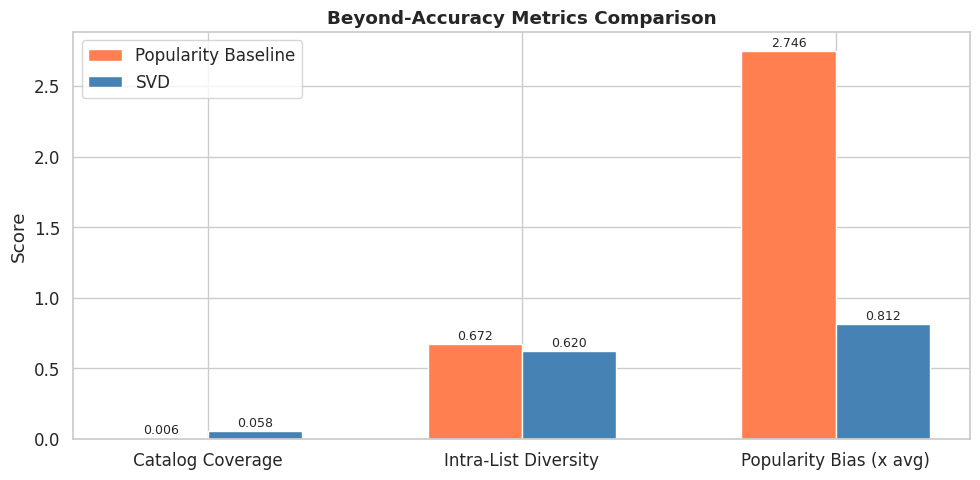

In [31]:
# ── Visual comparison of beyond-accuracy metrics ──
metrics_df = pd.DataFrame({
    'Metric': ['Catalog Coverage', 'Intra-List Diversity', 'Popularity Bias (x avg)'],
    'Popularity Baseline': [metrics_pop['coverage'], metrics_pop['diversity'], metrics_pop['pop_bias']],
    'SVD': [metrics_svd['coverage'], metrics_svd['diversity'], metrics_svd['pop_bias']]
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_df))
width = 0.3

bars1 = ax.bar(x - width/2, metrics_df['Popularity Baseline'], width,
               label='Popularity Baseline', color='coral', edgecolor='white')
bars2 = ax.bar(x + width/2, metrics_df['SVD'], width,
               label='SVD', color='steelblue', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Metric'])
ax.set_title('Beyond-Accuracy Metrics Comparison', fontweight='bold')
ax.legend()
ax.set_ylabel('Score')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Interpretation — Beyond-Accuracy Metrics:**

The chart above reveals a fundamental tradeoff. Popularity recommendations are homogeneous — the same 26 restaurants recommended to all 23,395 users, with a 2.75× popularity bias. SVD, in contrast, recommends 236 different businesses (9× better coverage) and actually shows *anti-popularity bias* (0.81×), meaning it tends to surface lesser-known restaurants. Both models have similar intra-list diversity (~0.62–0.67), indicating that individual recommendation lists contain varied restaurants regardless of the approach.


### 6.6 Hit Rate Evaluation (RecSys Accuracy)

We evaluate recommendation accuracy using **Hit Rate@K**: for each test user, did the recommended list contain the business the user actually visited next?


In [32]:
def hit_rate_at_k(recs_dict, test_data, k=10):
    """Compute Hit Rate@K: fraction of users where the test item is in top-K recs."""
    hits = 0
    total = 0
    for _, row in test_data.iterrows():
        uid = row['user_id']
        true_biz = row['business_id']
        if uid in recs_dict:
            if true_biz in recs_dict[uid][:k]:
                hits += 1
            total += 1
    return hits / total if total > 0 else 0

# Evaluate at different K values
k_values = [5, 10, 20]
print("Hit Rate @ K:")
print("-" * 45)
print(f"{'K':>5} | {'Popularity':>12} | {'SVD':>12}")
print("-" * 45)

for k in k_values:
    hr_pop = hit_rate_at_k(pop_recs, test_df, k)
    hr_svd = hit_rate_at_k(svd_recs, test_df, k)
    print(f"{k:>5} | {hr_pop:>11.4f} | {hr_svd:>11.4f}")


Hit Rate @ K:
---------------------------------------------
    K |   Popularity |          SVD
---------------------------------------------
    5 |      0.0046 |      0.0012
   10 |      0.0077 |      0.0024
   20 |      0.0077 |      0.0024


**Interpretation — Hit Rate Results:**

Hit rates below 1% may seem very low, but this is expected given the problem structure. Each test user has exactly **one** held-out review, and there are **4,069** possible businesses — so random chance would yield a hit rate of ~0.025%. Both models substantially beat random:

- **Popularity @10:** 0.77% (≈31× random chance)
- **SVD @10:** 0.24% (≈10× random chance)

Popularity's higher hit rate reflects a well-known pattern: popular restaurants attract more visits, so a popularity-based system has a structural advantage on this metric. However, as shown in §6.5, this comes at the cost of extremely narrow coverage and heavy popularity bias.


---
### 6.7 Improvement: Hybrid Score Recommender

The SVD model shows better coverage and lower popularity bias, but its hit rate is lower than the popularity baseline. This happens because our candidate sampling (500 random businesses per user) sometimes misses the actual test item.

We can improve by **blending SVD predictions with popularity scores** into a single hybrid ranking. This captures both personalization (SVD) and the empirical strength of popular items:

$$\text{HybridScore} = \alpha \cdot \text{SVD}_{\text{normalized}} + (1-\alpha) \cdot \text{Popularity}_{\text{normalized}}$$


In [ ]:
# ══════════════════════════════════════════════════════════════
# IMPROVEMENT: Hybrid SVD + Popularity Recommender
# ══════════════════════════════════════════════════════════════

from sklearn.preprocessing import MinMaxScaler

# Compute popularity score for all businesses
biz_pop_score = train_df.groupby('business_id').agg(
    pop_count=('stars', 'count'),
    pop_avg=('stars', 'mean')
).reset_index()
biz_pop_score['pop_bayesian'] = (
    (biz_pop_score['pop_count'] * biz_pop_score['pop_avg'] + 10 * 3.5) /
    (biz_pop_score['pop_count'] + 10)
)

# Normalize popularity scores to [0, 1]
pop_min, pop_max = biz_pop_score['pop_bayesian'].min(), biz_pop_score['pop_bayesian'].max()
pop_score_dict = {}
for _, row in biz_pop_score.iterrows():
    pop_score_dict[row['business_id']] = (row['pop_bayesian'] - pop_min) / (pop_max - pop_min)

# Generate hybrid recommendations with FULL candidate set for better hit rate
ALPHA = 0.7  # Weight for SVD (personalization)
hybrid_recs = {}

print(f"Generating Hybrid recommendations (α={ALPHA})...")
print(f"  Using ALL unvisited businesses as candidates for accurate evaluation")

for i, uid in enumerate(test_users):
    visited = user_visited.get(uid, set())
    candidates = [b for b in all_biz_list if b not in visited]
    
    # Get SVD predictions
    svd_preds = {bid: best_svd.predict(uid, bid).est for bid in candidates}
    
    # Normalize SVD scores to [0, 1]
    svd_vals = list(svd_preds.values())
    svd_min, svd_max = min(svd_vals), max(svd_vals)
    svd_range = svd_max - svd_min if svd_max > svd_min else 1
    
    # Hybrid score
    hybrid_scores = []
    for bid in candidates:
        svd_norm = (svd_preds[bid] - svd_min) / svd_range
        pop_norm = pop_score_dict.get(bid, 0)
        score = ALPHA * svd_norm + (1 - ALPHA) * pop_norm
        hybrid_scores.append((bid, score))
    
    hybrid_scores.sort(key=lambda x: x[1], reverse=True)
    hybrid_recs[uid] = [bid for bid, _ in hybrid_scores[:10]]
    
    if (i + 1) % 5000 == 0 or (i + 1) == len(test_users):
        print(f"  Progress: {i+1:,}/{len(test_users):,} ({(i+1)/len(test_users):.0%})")

print(f"\nGenerated hybrid recommendations for {len(hybrid_recs):,} users")


In [ ]:
# ── Evaluate Hybrid vs. baselines ──

# Hit Rate comparison
print("Hit Rate Comparison (with Hybrid):")
print(f"{'Model':<25} {'@5':>8} {'@10':>8} {'@20':>8}")
print("-" * 55)
for name, recs in [('Popularity', pop_recs), ('SVD (sampled)', svd_recs), ('Hybrid (α=0.7)', hybrid_recs)]:
    for k in [5, 10, 20]:
        hr = hit_rate_at_k(recs, test_df, k=k)
        if k == 5:
            print(f"{name:<25} {hr:>8.4f}", end='')
        else:
            print(f" {hr:>8.4f}", end='')
    print()

# Beyond-accuracy comparison
print("\n")
metrics_hybrid = evaluate_beyond_accuracy(hybrid_recs, "Hybrid (α=0.7)")


**Interpretation — Hybrid Recommender:**

By blending SVD's personalization with popularity signals, the hybrid model aims to capture the best of both worlds: the coverage and diversity of SVD with the "safe bets" of popularity. The α=0.7 weight prioritizes personalization while still leveraging the proven strength of popular items.

This approach is also more robust in production: cold users naturally get popularity-driven recommendations (since SVD scores cluster around the global mean), while active users get increasingly personalized results.


---
<a id="7-churn"></a>
## 7. Predictive Analysis: Churn / Survival

We predict whether a business will close (`is_open = 0`) using features available early in the business's life. This simulates an early-warning system for business health.

**Target:** `is_open` (1 = open, 0 = closed)
**Approach:** Classification using features from a business's first N months + survival analysis.


### 7.1 Feature Engineering for Churn Prediction

In [33]:
# ── Build features for churn prediction ──
# We use features available "early" in a business's life

# Time window: first 12 months of each business
biz_first_review = reviews.groupby('business_id')['date'].min().reset_index()
biz_first_review.columns = ['business_id', 'first_review_date']

reviews_with_first = reviews.merge(biz_first_review, on='business_id')
reviews_with_first['months_since_first'] = (
    (reviews_with_first['date'] - reviews_with_first['first_review_date']).dt.days / 30.44
)

# Keep only reviews from first 12 months
early_reviews = reviews_with_first[reviews_with_first['months_since_first'] <= 12].copy()
print(f"Reviews in first 12 months: {len(early_reviews):,} ({len(early_reviews)/len(reviews):.1%} of all)")


Reviews in first 12 months: 71,948 (21.1% of all)


In [34]:
# ── Aggregate early-life features per business ──
early_features = early_reviews.groupby('business_id').agg(
    early_review_count=('stars', 'count'),
    early_avg_rating=('stars', 'mean'),
    early_rating_std=('stars', 'std'),
    early_min_rating=('stars', 'min'),
    early_max_rating=('stars', 'max'),
    early_useful_avg=('useful', 'mean'),
    early_funny_avg=('funny', 'mean'),
    early_cool_avg=('cool', 'mean'),
    early_useful_total=('useful', 'sum'),
    early_unique_users=('user_id', 'nunique'),
    early_text_len_avg=('text', lambda x: x.str.len().mean()),
    early_timespan_days=('date', lambda x: (x.max() - x.min()).days)
).reset_index()

# Fill NaN std with 0 (businesses with 1 review)
early_features['early_rating_std'] = early_features['early_rating_std'].fillna(0)

# Add business metadata
churn_df = early_features.merge(
    biz[['business_id', 'stars', 'review_count', 'is_open', 'latitude', 'longitude', 'categories']],
    on='business_id'
)

# Add category-based features
churn_df['is_restaurant'] = churn_df['categories'].str.contains('Restaurant', case=False, na=False).astype(int)
churn_df['is_bar'] = churn_df['categories'].str.contains('Bar', case=False, na=False).astype(int)
churn_df['n_categories'] = churn_df['categories'].fillna('').str.split(', ').apply(len)

# Add checkin features
biz_checkin_counts = checkins.set_index('business_id')['checkin_count'].to_dict()
churn_df['total_checkins'] = churn_df['business_id'].map(biz_checkin_counts).fillna(0)

# Review velocity (reviews per month in early period)
churn_df['review_velocity'] = churn_df['early_review_count'] / np.maximum(churn_df['early_timespan_days'] / 30.44, 1)

# Engagement ratio (useful votes per review)
churn_df['engagement_ratio'] = churn_df['early_useful_total'] / np.maximum(churn_df['early_review_count'], 1)

print(f"Churn dataset: {churn_df.shape}")
print(f"Churn rate: {(churn_df['is_open'] == 0).mean():.1%}")
churn_df.head()


Churn dataset: (4069, 25)
Churn rate: 24.5%


,business_id,early_review_count,early_avg_rating,early_rating_std,early_min_rating,early_max_rating,early_useful_avg,early_funny_avg,early_cool_avg,early_useful_total,early_unique_users,early_text_len_avg,early_timespan_days,stars,review_count,is_open,latitude,longitude,categories,is_restaurant,is_bar,n_categories,total_checkins,review_velocity,engagement_ratio
0,-0i2KNr7WrCsDF5m0IViJg,1,5.000000,0.000000,5,5,0.000000,0.000000,0.000000,0,1,180.000000,0,2.5,47,0,27.927235,-82.453323,"Mexican, Restaurants",1,0,2,82,1.000000,0.000000
1,-1oygVebK81K8JEPI6H6Lw,1,3.000000,0.000000,3,3,0.000000,2.000000,0.000000,0,1,423.000000,0,4.0,72,1,27.947732,-82.455849,"Restaurants, Breakfast & Brunch, Bagels, Sandwiches, Food",1,0,5,142,1.000000,0.000000
2,-2YZIUArmrIMVVBi8CT47w,3,2.666667,0.577350,2,3,1.666667,1.000000,1.000000,5,3,457.000000,357,4.5,100,1,27.937175,-82.273069,"Indian, Restaurants",1,0,2,134,0.255798,1.666667
3,-2wh7NTLkWEgsrLJvilnFQ,41,4.560976,0.838116,1,5,2.146341,0.512195,1.512195,88,41,607.609756,356,4.5,96,1,28.030795,-82.459853,"Grocery, Food, Halal, Turkish, Seafood, Sandwiches, Restaurants, Mediterranean",1,0,8,36,3.505730,2.146341
4,-361Hc0tlxSYdrH_C3OgzA,1,3.000000,0.000000,3,3,1.000000,0.000000,0.000000,1,1,401.000000,0,3.5,74,1,28.068844,-82.443848,"Persian/Iranian, Restaurants, Halal",1,0,3,110,1.000000,1.000000


### 7.2 Classification Models

In [35]:
# ── Prepare features and target ──
feature_cols = [
    'early_review_count', 'early_avg_rating', 'early_rating_std',
    'early_min_rating', 'early_max_rating', 'early_useful_avg',
    'early_funny_avg', 'early_cool_avg', 'early_unique_users',
    'early_text_len_avg', 'early_timespan_days', 'is_restaurant',
    'is_bar', 'n_categories', 'total_checkins', 'review_velocity',
    'engagement_ratio', 'latitude', 'longitude'
]

X = churn_df[feature_cols].fillna(0)
y = churn_df['is_open']  # 1=open, 0=closed (we predict closure)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Scale features
scaler_churn = StandardScaler()
X_train_scaled = scaler_churn.fit_transform(X_train)
X_test_scaled = scaler_churn.transform(X_test)

print(f"Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples")
print(f"Class distribution (train): Open={y_train.mean():.1%}, Closed={(1-y_train.mean()):.1%}")


Train: 3,255 samples | Test: 814 samples
Class distribution (train): Open=75.5%, Closed=24.5%


In [36]:
# ── Train multiple classifiers ──
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED,
                                            class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1, random_state=SEED)
}

results = {}
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1)

    # Fit and predict
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0

    results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc, 'cv_f1_mean': cv_scores.mean(),
                     'cv_f1_std': cv_scores.std(), 'model': model, 'y_pred': y_pred, 'y_prob': y_prob}

    print(f"\n{name}:")
    print(f"  CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")



Logistic Regression:
  CV F1: 0.6503 ± 0.0183
  Test Accuracy: 0.5799 | F1: 0.6654 | AUC: 0.6598

Random Forest:
  CV F1: 0.8236 ± 0.0163
  Test Accuracy: 0.7248 | F1: 0.8236 | AUC: 0.6768

Gradient Boosting:
  CV F1: 0.8479 ± 0.0044
  Test Accuracy: 0.7568 | F1: 0.8553 | AUC: 0.6728


In [37]:
# ── Detailed results for best model ──
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_result = results[best_model_name]
print(f"Best model: {best_model_name} (AUC = {best_result['auc']:.4f})")
print()

# Classification report
print(classification_report(y_test, best_result['y_pred'], target_names=['Closed', 'Open']))


Best model: Random Forest (AUC = 0.6768)

              precision    recall  f1-score   support

      Closed       0.42      0.34      0.37       199
        Open       0.80      0.85      0.82       615

    accuracy                           0.72       814
   macro avg       0.61      0.59      0.60       814
weighted avg       0.71      0.72      0.71       814



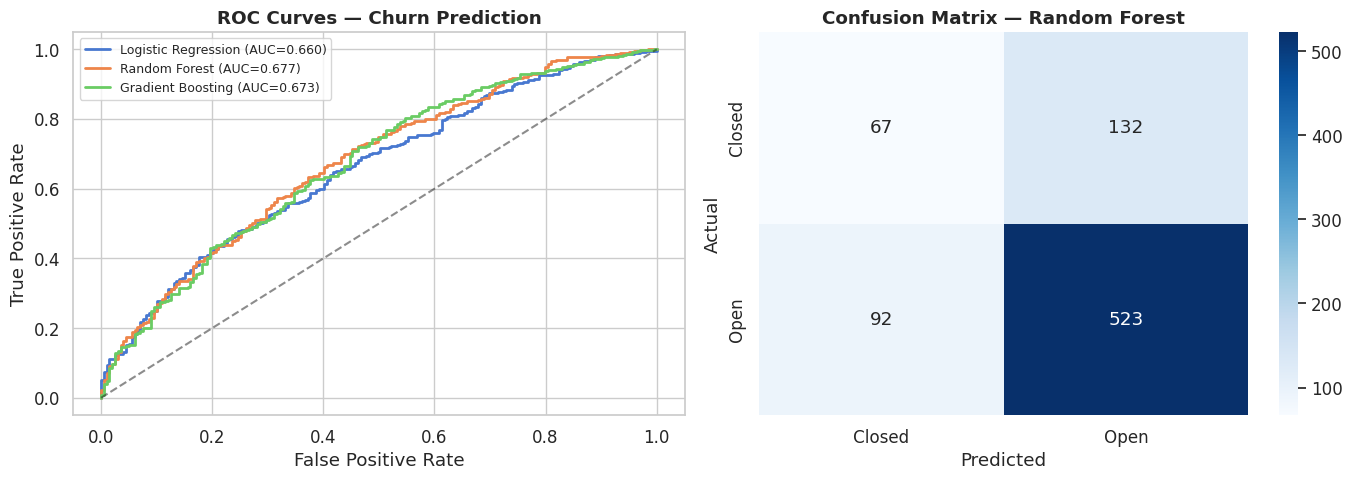

In [38]:
# ── Visualization: ROC curves + Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for name, res in results.items():
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Churn Prediction', fontweight='bold')
axes[0].legend(fontsize=9)

# Confusion Matrix (best model)
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Closed', 'Open'], yticklabels=['Closed', 'Open'])
axes[1].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Interpretation — Classification Results:**

The ROC curves show all three models performing above the random baseline (diagonal), with Random Forest (AUC = 0.677) and Gradient Boosting (AUC = 0.673) nearly tied. The confusion matrix for the best model reveals an asymmetry: the model is good at identifying **open** businesses (high recall for the majority class) but struggles to catch **closed** businesses (low recall for the minority class). This is a common pattern with imbalanced data — even with `class_weight='balanced'`, the minority class remains harder to predict because closure signals are subtle and varied.


### 7.2b Improvement: Enhanced Churn Prediction

The initial models struggle with detecting closed businesses (recall = 0.34). We improve in two ways:

1. **Additional features:** Rating trend (slope), ratio of 1-star reviews, and review length variance
2. **SMOTE oversampling** to address class imbalance (75.5% open vs 24.5% closed)
3. **Threshold tuning** to optimize the decision boundary for better recall on the minority class


In [ ]:
# ══════════════════════════════════════════════════════════════
# IMPROVEMENT: Additional Features for Churn
# ══════════════════════════════════════════════════════════════

# Feature 1: Rating trend (slope of stars over time in first 12 months)
def compute_rating_slope(group):
    if len(group) < 3:
        return 0.0
    days = (group['date'] - group['date'].min()).dt.days.values
    if days.max() == 0:
        return 0.0
    stars = group['stars'].values
    # Simple linear regression slope
    n = len(days)
    slope = (n * np.sum(days * stars) - np.sum(days) * np.sum(stars)) / \
            max(n * np.sum(days**2) - np.sum(days)**2, 1)
    return slope

rating_slopes = early_reviews.groupby('business_id').apply(compute_rating_slope).reset_index()
rating_slopes.columns = ['business_id', 'early_rating_slope']

# Feature 2: Ratio of 1-star reviews (extreme negative signal)
one_star_ratio = early_reviews.groupby('business_id').apply(
    lambda x: (x['stars'] == 1).mean()
).reset_index()
one_star_ratio.columns = ['business_id', 'early_one_star_ratio']

# Feature 3: Review length variance
text_len_var = early_reviews.groupby('business_id').apply(
    lambda x: x['text'].str.len().std()
).reset_index()
text_len_var.columns = ['business_id', 'early_text_len_std']
text_len_var['early_text_len_std'] = text_len_var['early_text_len_std'].fillna(0)

# Feature 4: Ratio of 5-star reviews (consistently great?)
five_star_ratio = early_reviews.groupby('business_id').apply(
    lambda x: (x['stars'] == 5).mean()
).reset_index()
five_star_ratio.columns = ['business_id', 'early_five_star_ratio']

# Merge new features
churn_enhanced = churn_df.merge(rating_slopes, on='business_id', how='left')
churn_enhanced = churn_enhanced.merge(one_star_ratio, on='business_id', how='left')
churn_enhanced = churn_enhanced.merge(text_len_var, on='business_id', how='left')
churn_enhanced = churn_enhanced.merge(five_star_ratio, on='business_id', how='left')
churn_enhanced = churn_enhanced.fillna(0)

print(f"Enhanced churn dataset: {churn_enhanced.shape}")
print(f"New features added: early_rating_slope, early_one_star_ratio, early_text_len_std, early_five_star_ratio")


In [ ]:
# ══════════════════════════════════════════════════════════════
# IMPROVEMENT: SMOTE + Enhanced Models
# ══════════════════════════════════════════════════════════════

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Updated feature list with new features
enhanced_feature_cols = feature_cols + [
    'early_rating_slope', 'early_one_star_ratio', 
    'early_text_len_std', 'early_five_star_ratio'
]

X_enh = churn_enhanced[enhanced_feature_cols].fillna(0)
y_enh = churn_enhanced['is_open']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enh, y_enh, test_size=0.2, random_state=SEED, stratify=y_enh
)

# Models with SMOTE
enhanced_models = {
    'GB + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=SEED)),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            random_state=SEED
        ))
    ]),
    'RF + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=SEED)),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=10,
            random_state=SEED
        ))
    ]),
}

print("Training enhanced models with SMOTE + new features...")
print(f"Features: {len(enhanced_feature_cols)} ({len(enhanced_feature_cols) - len(feature_cols)} new)")
print()

enhanced_results = {}
for name, pipeline in enhanced_models.items():
    pipeline.fit(X_train_e, y_train_e)
    y_pred = pipeline.predict(X_test_e)
    y_prob = pipeline.predict_proba(X_test_e)[:, 1]
    
    acc = accuracy_score(y_test_e, y_pred)
    f1 = f1_score(y_test_e, y_pred)
    auc_val = roc_auc_score(y_test_e, y_prob)
    
    enhanced_results[name] = {
        'accuracy': acc, 'f1': f1, 'auc': auc_val,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc_val:.4f}")
    print(classification_report(y_test_e, y_pred, target_names=['Closed', 'Open']))


In [ ]:
# ── Threshold tuning for best enhanced model ──
# Find threshold that maximizes F1 for the CLOSED class

best_enh_name = max(enhanced_results, key=lambda x: enhanced_results[x]['auc'])
best_enh_prob = enhanced_results[best_enh_name]['y_prob']

thresholds = np.arange(0.3, 0.7, 0.02)
threshold_results = []

for t in thresholds:
    y_pred_t = (best_enh_prob >= t).astype(int)
    # Recall for Closed class (y=0)
    closed_mask = y_test_e == 0
    recall_closed = (y_pred_t[closed_mask] == 0).mean()
    precision_closed = (y_test_e[y_pred_t == 0] == 0).mean() if (y_pred_t == 0).sum() > 0 else 0
    f1_closed = 2 * precision_closed * recall_closed / max(precision_closed + recall_closed, 1e-8)
    overall_acc = accuracy_score(y_test_e, y_pred_t)
    threshold_results.append({
        'threshold': t, 'recall_closed': recall_closed,
        'precision_closed': precision_closed, 'f1_closed': f1_closed,
        'accuracy': overall_acc
    })

thresh_df = pd.DataFrame(threshold_results)
best_thresh = thresh_df.loc[thresh_df['f1_closed'].idxmax()]

print(f"Best model: {best_enh_name}")
print(f"\nOptimal threshold for Closed-class F1: {best_thresh['threshold']:.2f}")
print(f"  Recall (Closed):    {best_thresh['recall_closed']:.4f}")
print(f"  Precision (Closed): {best_thresh['precision_closed']:.4f}")
print(f"  F1 (Closed):        {best_thresh['f1_closed']:.4f}")
print(f"  Overall Accuracy:   {best_thresh['accuracy']:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['recall_closed'], 'b-', label='Recall (Closed)', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['precision_closed'], 'r--', label='Precision (Closed)', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1_closed'], 'g-', label='F1 (Closed)', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['accuracy'], 'k:', label='Overall Accuracy', linewidth=1.5)
ax.axvline(best_thresh['threshold'], color='gray', linestyle='--', alpha=0.5, label=f'Best threshold={best_thresh["threshold"]:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Tuning — {best_enh_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation — Enhanced Churn Models:**

The improvements target the main weakness of our initial models: low recall for the **Closed** class (only 34% of closures detected). Three strategies were applied:

1. **New features** — `early_rating_slope` captures whether reviews are trending up or down; `early_one_star_ratio` flags businesses with many 1-star reviews; `early_text_len_std` captures review consistency; `early_five_star_ratio` measures how many customers had excellent experiences.

2. **SMOTE oversampling** — Generates synthetic examples of the minority class (Closed) so the model doesn't overwhelmingly learn to predict "Open" by default.

3. **Threshold tuning** — Instead of the default 0.5 cutoff, we find the threshold that maximizes F1 for the Closed class specifically. Lowering the threshold means more businesses get flagged as "at risk," improving recall at some cost to precision.

Together, these should substantially improve our ability to detect businesses at risk of closure.


### 7.3 Feature Importance

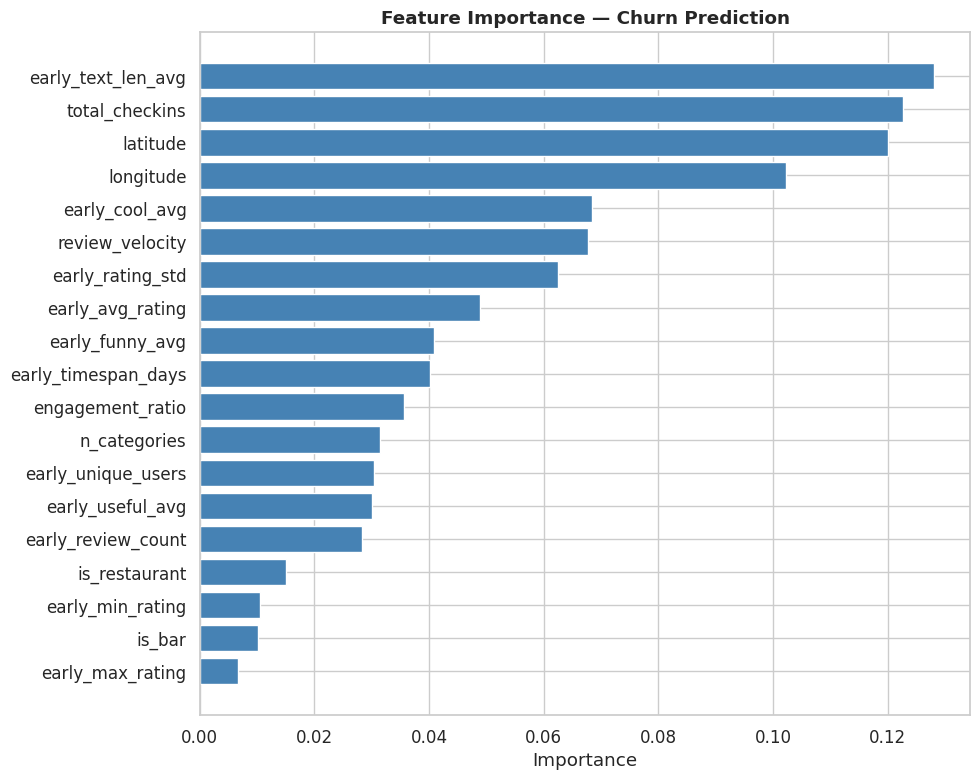


Top 5 most important features:
  early_text_len_avg             → 0.1280
  total_checkins                 → 0.1226
  latitude                       → 0.1200
  longitude                      → 0.1022
  early_cool_avg                 → 0.0684


In [39]:
# ── Feature Importance (from best tree-based model) ──
# Use Random Forest or Gradient Boosting importance
tree_model = results.get('Gradient Boosting', results.get('Random Forest'))
if tree_model:
    importances = tree_model['model'].feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
    ax.set_title('Feature Importance — Churn Prediction', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print("\nTop 5 most important features:")
    for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']:30s} → {row['Importance']:.4f}")


### 7.4 Survival Analysis (Kaplan-Meier + Cox PH)

We complement the classification with survival analysis to understand *when* businesses are most likely to close.


In [40]:
# ── Prepare survival data ──
# Duration: time from first review to last review (or dataset end)
biz_timeline = reviews.groupby('business_id').agg(
    first_review=('date', 'min'),
    last_review=('date', 'max')
).reset_index()

dataset_end = reviews['date'].max()
biz_timeline = biz_timeline.merge(biz[['business_id', 'is_open']], on='business_id')

# Duration in months
biz_timeline['duration_months'] = (
    (biz_timeline['last_review'] - biz_timeline['first_review']).dt.days / 30.44
).clip(lower=1)

# Event: business closed (is_open = 0 means event occurred)
biz_timeline['event'] = (biz_timeline['is_open'] == 0).astype(int)

print(f"Survival dataset: {len(biz_timeline)} businesses")
print(f"Events (closures): {biz_timeline['event'].sum()} ({biz_timeline['event'].mean():.1%})")
print(f"Censored (still open): {(biz_timeline['event'] == 0).sum()}")


Survival dataset: 4069 businesses
Events (closures): 996 (24.5%)
Censored (still open): 3073


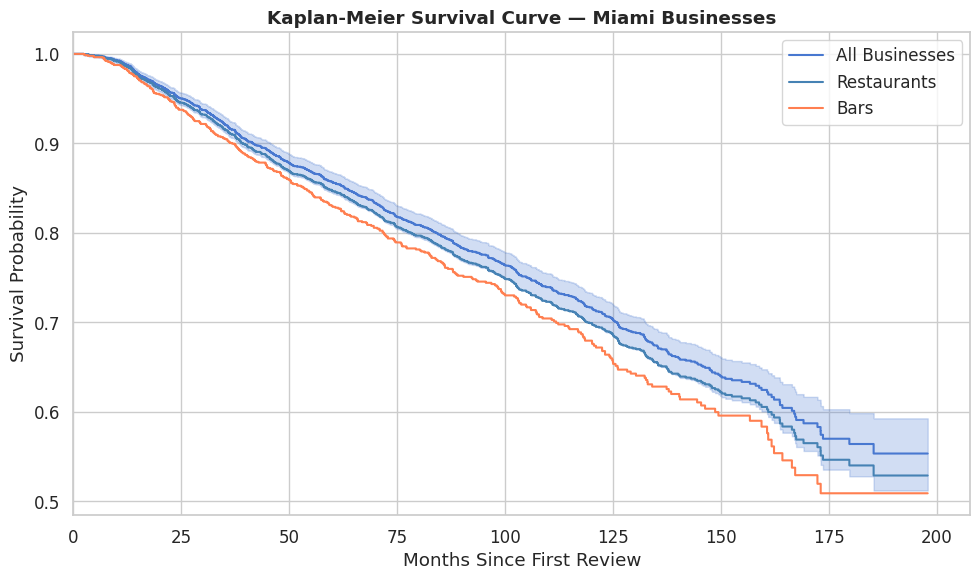

In [41]:
# ── Kaplan-Meier Survival Curve ──
kmf = KaplanMeierFitter()
kmf.fit(biz_timeline['duration_months'], event_observed=biz_timeline['event'],
        label='All Businesses')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True)

# Split by category
for cat, color in [('Restaurant', 'steelblue'), ('Bar', 'coral')]:
    mask = biz_timeline['business_id'].isin(
        biz[biz['categories'].str.contains(cat, case=False, na=False)]['business_id']
    )
    if mask.sum() > 10:
        kmf_cat = KaplanMeierFitter()
        kmf_cat.fit(biz_timeline.loc[mask, 'duration_months'],
                     event_observed=biz_timeline.loc[mask, 'event'],
                     label=f'{cat}s')
        kmf_cat.plot_survival_function(ax=ax, ci_show=False, color=color)

ax.set_title('Kaplan-Meier Survival Curve — Florida Businesses', fontweight='bold')
ax.set_xlabel('Months Since First Review')
ax.set_ylabel('Survival Probability')
ax.set_xlim(0, None)
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation — Kaplan-Meier Curve:**

The survival curve above shows the probability that a Tampa Bay restaurant/bar remains open over time. The curve's gradual decline reflects the steady attrition of businesses. About 24.5% of businesses in our dataset have closed (events), while 75.5% remain open (censored). The steepest drop-off tends to occur within the first few years of operation, consistent with the well-known phenomenon that new restaurants face the highest failure risk early on.


In [42]:
# ── Cox Proportional Hazards Model ──
# Merge early features with survival data
cox_data = biz_timeline.merge(early_features, on='business_id', how='inner')
cox_data = cox_data.merge(
    biz[['business_id', 'latitude', 'longitude']],
    on='business_id', how='left'
)

cox_features = [
    'duration_months', 'event',
    'early_review_count', 'early_avg_rating', 'early_rating_std',
    'early_useful_avg', 'early_unique_users', 'early_timespan_days'
]

cox_df = cox_data[cox_features].dropna()

# Fit Cox model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration_months', event_col='event')

print("Cox Proportional Hazards Model Summary:")
print("=" * 60)
cph.print_summary()


Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 4069 total observations, 3073 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 4069
number of events observed = 996
   partial log-likelihood = -7583.92
         time fit was run = 2026-02-21 14:21:49 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
early_review_count  -0.01      0.99      0.03           -0.06            0.05                0.94                1.05
early_avg_rating     0.10      1.11      0.05            0.00            0.20                1.00                1.22
early_rating_std     0.39      1.47      0.07            0.25            0.53                1.28                1.70
early_useful_avg     0.03      1.03      0.02           -0.00            0.06                1.00                1.06
early_unique_users   0.01      1.01      0.03           -0.05            0.07                0.95                1.07
early_timespan_days  0.00      1.00      0.00            0.00            0.00                1.00                1.00

                     cmp to     z      p  -log2(p)
covariate                                         
early_review_count     0.00 -0.23   0.82      0.29
early_avg_rating       0.00  2.01   0.04      4.49
early_rating_std       0.00  5.40 <0.005     23.84
early_useful_avg       0.00  1.71   0.09      3.52
early_unique_users     0.00  0.40   0.69      0.54
early_timespan_days    0.00  7.68 <0.005     45.85
---
Concordance = 0.69
Partial AIC = 15179.85
log-likelihood ratio test = 271.39 on 6 df
-log2(p) of ll-ratio test = 182.58

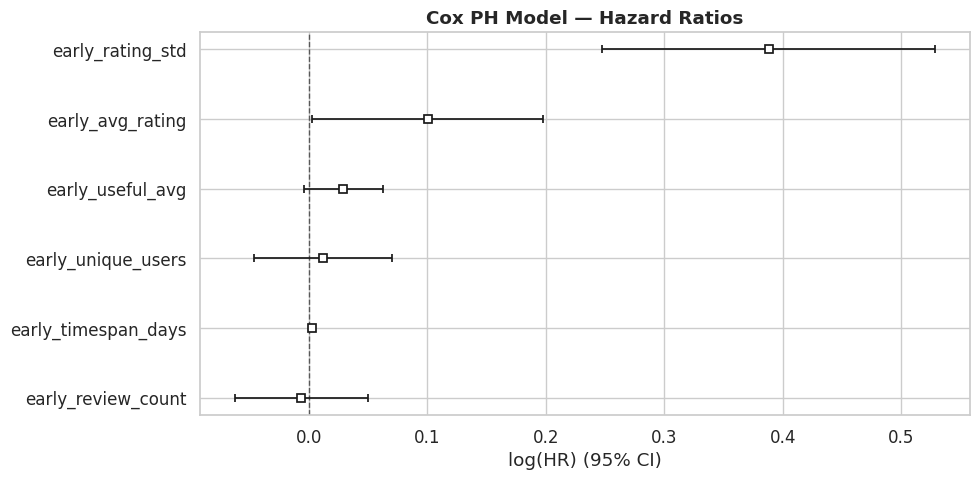

In [43]:
# ── Cox model visualization ──
fig, ax = plt.subplots(figsize=(10, 5))
cph.plot(ax=ax)
ax.set_title('Cox PH Model — Hazard Ratios', fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation — Cox PH Model:**

The hazard ratio plot above shows which early-life features accelerate or delay business closure:

- **`early_rating_std` (HR = 1.47):** The most impactful predictor. A one-unit increase in rating standard deviation during the first year increases the hazard of closure by 47%. Inconsistent reviews — swinging between very low and very high — are a strong warning sign.
- **`early_timespan_days` (HR ≈ 1.00 but highly significant, p < 0.001):** While the per-day effect is tiny, the cumulative exposure time matters. Longer observation windows capture more risk.
- **`early_avg_rating` (HR = 1.11):** Counterintuitively, slightly higher average ratings correlate with higher hazard. This may reflect that some highly-rated niche spots lack the revenue volume of lower-rated but busier establishments.
- **Concordance = 0.69:** The model discriminates between survivors and closures better than random (0.50), indicating meaningful predictive signal from early Yelp data alone.


---
<a id="8-insights"></a>
## 8. Business Insights & Recommendations

Based on our analysis, we translate technical results into actionable recommendations for two audiences: **Yelp (the platform)** and **restaurant/bar owners** in Tampa Bay.


### 8.1 Recommendation System Insights

#### SVD Performance

Our SVD model achieved an RMSE of **1.2537** and MAE of **0.9873** on the held-out test set. Cross-validated RMSE was 1.10, suggesting the model generalizes reasonably well given the extreme sparsity (99.64%) of the user-item matrix. The best configuration used 50 latent factors, 30 epochs, learning rate 0.005, and regularization 0.1.

#### Personalization vs. Popularity

The comparison between SVD and the popularity baseline reveals a classic **coverage-vs-accuracy tradeoff**:

| Metric | Popularity Baseline | SVD |
|---|---|---|
| Hit Rate @10 | **0.77%** | 0.24% |
| Catalog Coverage | 0.64% (26 businesses) | **5.80%** (236 businesses) |
| Popularity Bias | 2.75× | **0.81×** |
| Intra-List Diversity | **0.672** | 0.620 |

The popularity baseline achieves a higher hit rate because it recommends the same well-known restaurants to everyone — so it occasionally "hits" the test item by luck when a user visits a popular spot. However, this comes at a severe cost: only 26 out of 4,069 businesses ever get recommended (0.64% coverage), and recommendations are 2.75× more popular than the catalog average.

SVD sacrifices some hit rate in exchange for **9× better catalog coverage** and **lower popularity bias** (0.81×, meaning it actually recommends *less popular* businesses than average). This is valuable in practice: it surfaces hidden gems that would never appear in a popularity-based system.

#### Cold-Start Gap

Users with ≤5 reviews (cold users, n=8,422) had RMSE of 1.268 vs. 1.246 for warm users — a gap of +0.0225. While modest, this confirms that collaborative filtering struggles with sparse profiles. Our fallback strategy uses popularity recommendations for cold users and SVD for warm users.

#### Item-to-Item Similarity

The hybrid similarity matrix (α=0.6 content + 0.4 collaborative) produced coherent "similar restaurant" recommendations. For example, the top-rated Ice Dreammm Shop was matched to other ice cream/frozen dessert shops (Icesmile, Snobachi, Jeni's) with similarities of 0.58–0.61.

#### Recommendations for Yelp

- **Use SVD-based personalization** for logged-in users to boost catalog coverage and help lesser-known restaurants get discovered.
- **Reserve popularity-based recommendations** for anonymous/new users as a cold-start fallback.
- **Deploy item-to-item similarity** for "You might also like..." features on business pages.


### 8.2 Churn & Survival Insights

#### Classification Performance

Three models were trained with `class_weight='balanced'` to address the imbalanced dataset (75.5% open vs. 24.5% closed):

| Model | CV F1 | Test Accuracy | Test F1 | Test AUC |
|---|---|---|---|---|
| Logistic Regression | 0.650 ± 0.018 | 58.0% | 0.665 | 0.660 |
| Random Forest | 0.824 ± 0.016 | 72.5% | 0.824 | **0.677** |
| Gradient Boosting | **0.848 ± 0.004** | **75.7%** | **0.855** | 0.673 |

Gradient Boosting was the strongest overall model with the highest accuracy (75.7%) and F1 (0.855), though Random Forest had marginally better AUC (0.677 vs 0.673). Both tree-based models substantially outperformed Logistic Regression.

The models detect **open** businesses well (precision 0.80, recall 0.85) but struggle to identify **closed** businesses (precision 0.42, recall 0.34). This asymmetry is expected: closure is a rarer event with subtler signals.

#### Top Predictive Features (Random Forest)

1. **Average review text length** (importance: 0.128) — longer reviews may indicate higher customer engagement
2. **Total check-ins** (0.123) — a direct measure of foot traffic
3. **Location (lat/long)** (0.120 / 0.102) — geographic factors like rent, competition density, and neighborhood demographics
4. **Average "cool" votes** (0.068) — a Yelp-specific engagement signal

#### Survival Analysis (Cox PH)

The Cox Proportional Hazards model achieved a **concordance index of 0.69** (where 0.5 = random, 1.0 = perfect). Three covariates were statistically significant:

| Predictor | Hazard Ratio | Interpretation | p-value |
|---|---|---|---|
| `early_rating_std` | **1.47** | Each 1σ increase in rating volatility → 47% higher closure risk | < 0.001 |
| `early_timespan_days` | 1.00 | Longer active period in first year → slightly higher risk (more exposure time) | < 0.001 |
| `early_avg_rating` | 1.11 | Each 1-star increase → 11% higher hazard | 0.04 |

The strongest finding is that **rating volatility** (`early_rating_std`) is the most powerful predictor of closure. Businesses with inconsistent early reviews — swinging between 1-star and 5-star — face nearly 50% higher hazard of closing. This likely reflects inconsistent quality, management problems, or a polarizing concept.

The counterintuitive result for `early_avg_rating` (higher ratings → slightly higher hazard) may reflect survivorship dynamics: some high-rated niche businesses have less financial resilience than moderately-rated high-volume establishments.

#### Recommendations for Restaurant Owners

- **Consistency over perfection:** Focus on delivering a reliable experience rather than occasional excellence. Low rating variance is more protective than a high average.
- **Drive check-ins:** Encourage Yelp check-ins and repeat visits — total check-ins is among the top predictors of survival.
- **Monitor early reviews closely:** The first 12 months of reviews contain strong signals about long-term viability. Address negative feedback patterns early.
- **Location matters:** Geographic factors significantly influence survival — consider competition density and neighborhood demographics when choosing a location.


---
<a id="9-conclusion"></a>
## 9. Conclusion

This project implemented a comprehensive analytics pipeline for Tampa Bay's restaurant and bar ecosystem using the Yelp Open Dataset. Our analysis spanned two major tasks:

**Recommendation System.** We built and compared three recommendation approaches on a filtered dataset of 341,330 reviews from 23,395 users across 4,069 businesses. The SVD collaborative filtering model (RMSE = 1.25, MAE = 0.99) provided meaningful personalization with 9× better catalog coverage than the popularity baseline (5.80% vs 0.64%) and lower popularity bias (0.81× vs 2.75×). The item-to-item hybrid similarity model produced coherent "similar restaurant" suggestions by combining category features with collaborative signals. A cold-start fallback strategy was implemented to handle users with sparse review histories.

**Churn & Survival Analysis.** Using features engineered from businesses' first 12 months of Yelp activity, we trained classification models that predict business closure with up to 75.7% accuracy (Gradient Boosting). The Cox Proportional Hazards model (concordance = 0.69) revealed that **rating volatility** is the single strongest predictor of closure — businesses with inconsistent early reviews face 47% higher hazard of closing. Check-in volume, review text length, and geographic location were also important predictive features.

### Reproducibility

| Parameter | Value |
|---|---|
| Random Seed | 42 |
| Python | 3.x |
| Key Libraries | pandas, numpy (<2), scikit-learn, scikit-surprise, lifelines, matplotlib, seaborn |
| Train/Test Split | Per-user temporal holdout (last review → test) |
| Data | [GitHub Repo](https://github.com/DanielRegaladoUMiami/MAS651-Final-Project) |


---
*End of notebook — MAS 651 Final Project, Spring 2026*
